In [84]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Membaca Dataset
df = pd.read_csv("Survei Beban Tugas & Tingkat Stres Mahasiswa  (Jawaban)(Form Responses 1) (1).csv")

In [85]:
# 2. Data Cleaning
# Menghapus duplikat berdasarkan NIM agar data valid
df = df.drop_duplicates(subset=['NIM'])

In [86]:
# 3. Feature Selection
X = df[['jumlah tugas', 'jumlah deadline', 'rata rata jam tidur']]
y = df['Stress']

In [87]:
# 4. Split Data (75% Training, 25% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [88]:
# 5. Training Model dengan Perceptron
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [89]:
# 6. Prediction
y_pred = model.predict(X_test)

In [90]:
# 7. Prediksi
print("7. EVALUATION")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

7. EVALUATION
Accuracy: 0.36363636363636365

Confusion Matrix:
 [[1 0]
 [7 3]]

Classification Report:
               precision    recall  f1-score   support

           0       0.12      1.00      0.22         1
           1       1.00      0.30      0.46        10

    accuracy                           0.36        11
   macro avg       0.56      0.65      0.34        11
weighted avg       0.92      0.36      0.44        11



In [91]:
# 8. Probabilitas Prediksi
print("\n8. PROBABILITAS PREDIKSI")
probabilitas = model.predict_proba(X_test)

# Menampilkan probabilitas dipasangkan dengan hasil tebakan
for i, prob in enumerate(probabilitas):
    print(f"Data ke-{i+1}: {prob} -> "
          f"({prob[0]*100:.1f}% Tidak Stress, {prob[1]*100:.1f}% Stress)")


8. PROBABILITAS PREDIKSI
Data ke-1: [0.25934888 0.74065112] -> (25.9% Tidak Stress, 74.1% Stress)
Data ke-2: [0.72920115 0.27079885] -> (72.9% Tidak Stress, 27.1% Stress)
Data ke-3: [0.74049281 0.25950719] -> (74.0% Tidak Stress, 26.0% Stress)
Data ke-4: [0.50519439 0.49480561] -> (50.5% Tidak Stress, 49.5% Stress)
Data ke-5: [0.48012037 0.51987963] -> (48.0% Tidak Stress, 52.0% Stress)
Data ke-6: [0.65538217 0.34461783] -> (65.5% Tidak Stress, 34.5% Stress)
Data ke-7: [0.70893857 0.29106143] -> (70.9% Tidak Stress, 29.1% Stress)
Data ke-8: [0.69683604 0.30316396] -> (69.7% Tidak Stress, 30.3% Stress)
Data ke-9: [0.8956559 0.1043441] -> (89.6% Tidak Stress, 10.4% Stress)
Data ke-10: [0.6188065 0.3811935] -> (61.9% Tidak Stress, 38.1% Stress)
Data ke-11: [0.30961851 0.69038149] -> (31.0% Tidak Stress, 69.0% Stress)


In [ ]:
# 9. Visualisasi
# A. Membuat Tabel Hasil Prediksi (Sekarang dilengkapi Probabilitas!)
results_df = X_test.copy()
results_df['Actual Stress'] = y_test
results_df['Predicted Stress'] = y_pred
results_df['Benar/Salah'] = results_df['Actual Stress'] == results_df['Predicted Stress']

# Menambahkan kolom probabilitas ke dalam tabel
# probabilitas[:, 1] mengambil kolom probabilitas untuk kelas 1 (Stress)
results_df['Peluang Stress (%)'] = np.round(probabilitas[:, 1] * 100, 1)

print("\nSAMPLE TSSABEL HASIL PREDIKSI")
print(results_df.head())
# Simpan ke CSV untuk dikumpulkan
results_df.to_csv("Hasil_Prediksi_LogisticRegression.csv", index=False)


SAMPLE TABEL HASIL PREDIKSI
    jumlah tugas  jumlah deadline  rata rata jam tidur  Actual Stress  \
24             6                2                    5              1   
13             3                2                    6              1   
8              3                1                    5              0   
25             4                3                    6              1   
4              5                1                    5              1   

    Predicted Stress  Benar/Salah  Peluang Stress (%)  
24                 1         True                74.1  
13                 0        False                27.1  
8                  0         True                26.0  
25                 0        False                49.5  
4                  1         True                52.0  


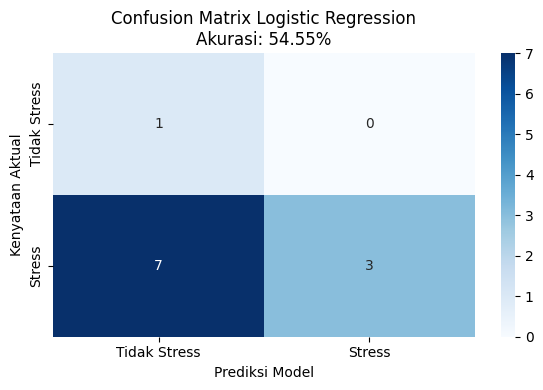

In [93]:
# B. Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Tidak Stress', 'Stress'], 
            yticklabels=['Tidak Stress', 'Stress'])
plt.xlabel('Prediksi Model')
plt.ylabel('Kenyataan Aktual')
plt.title(f'Confusion Matrix Logistic Regression\nAkurasi: {acc*100:.2f}%')
plt.tight_layout()
plt.savefig('confusion_matrix_logreg.png')
plt.show()

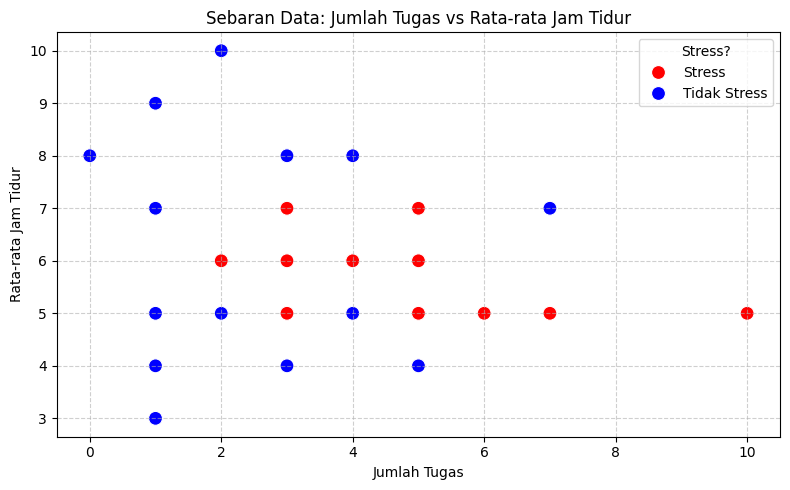

In [94]:
# C. Scatter Plot Persebaran Data
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='jumlah tugas', y='rata rata jam tidur', 
                hue='Stress?', palette={'Tidak Stress': 'blue', 'Stress': 'red'}, s=100)
plt.title('Sebaran Data: Jumlah Tugas vs Rata-rata Jam Tidur')
plt.xlabel('Jumlah Tugas')
plt.ylabel('Rata-rata Jam Tidur')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('scatter_plot_data.png')
plt.show()